In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
import warnings
warnings.filterwarnings("ignore")

# Connect to BigQuery
client = bigquery.Client(project="project-a13303d6-d497-41fa-ab8")
print("✅ Connected to BigQuery!")

# Load prices from BigQuery
prices = client.query("""
    SELECT * FROM `project-a13303d6-d497-41fa-ab8.market_intelligence.prices`
    ORDER BY asset, date
""").to_dataframe()

# Load sentiment from BigQuery
sentiment = client.query("""
    SELECT * FROM `project-a13303d6-d497-41fa-ab8.market_intelligence.news_sentiment`
    ORDER BY asset, date
""").to_dataframe()

print(f"Prices loaded: {len(prices)} rows")
print(f"Sentiment loaded: {len(sentiment)} rows")

✅ Connected to BigQuery!
Prices loaded: 3568 rows
Sentiment loaded: 383 rows


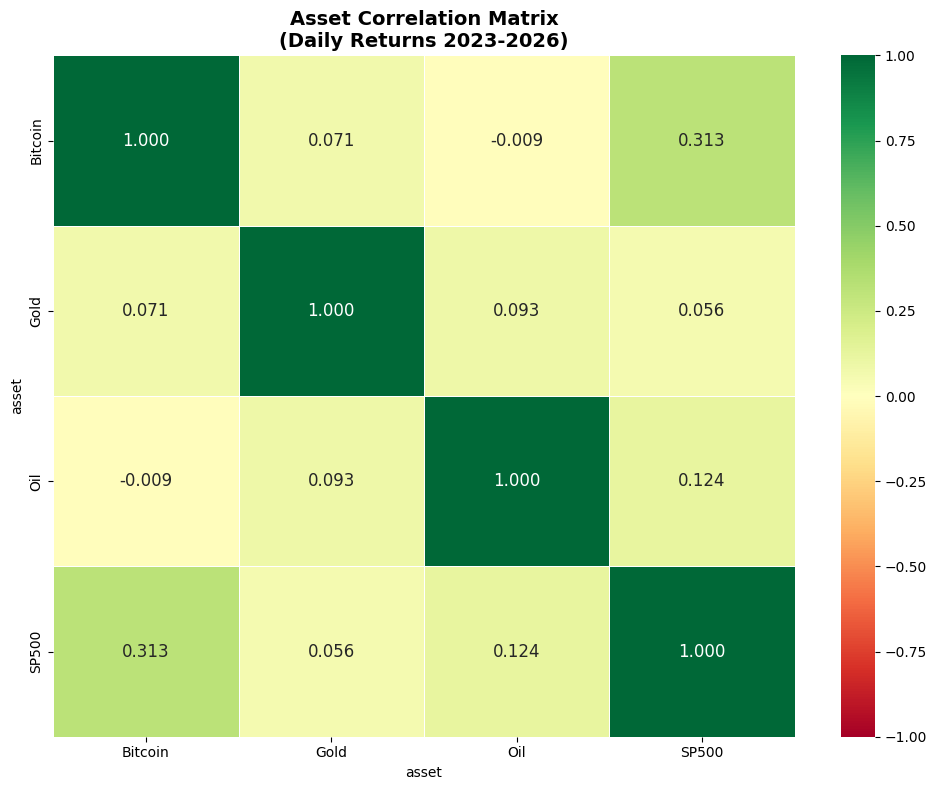

=== CORRELATION INSIGHTS ===
asset     Bitcoin      Gold       Oil     SP500
asset                                          
Bitcoin  1.000000  0.070616 -0.008626  0.312690
Gold     0.070616  1.000000  0.093455  0.056075
Oil     -0.008626  0.093455  1.000000  0.124249
SP500    0.312690  0.056075  0.124249  1.000000


In [2]:
# ============================================================
# CORRELATION ANALYSIS — HOW ASSETS MOVE TOGETHER
# ============================================================

# Pivot prices to wide format
prices["date"] = pd.to_datetime(prices["date"])
prices_pivot = prices.pivot(index="date", columns="asset", values="close")

# Calculate correlation matrix
corr_matrix = prices_pivot.pct_change().corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".3f",
            cmap="RdYlGn",
            center=0,
            vmin=-1, vmax=1,
            ax=ax,
            linewidths=0.5,
            annot_kws={"size": 12})

ax.set_title("Asset Correlation Matrix\n(Daily Returns 2023-2026)", 
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== CORRELATION INSIGHTS ===")
print(corr_matrix.to_string())

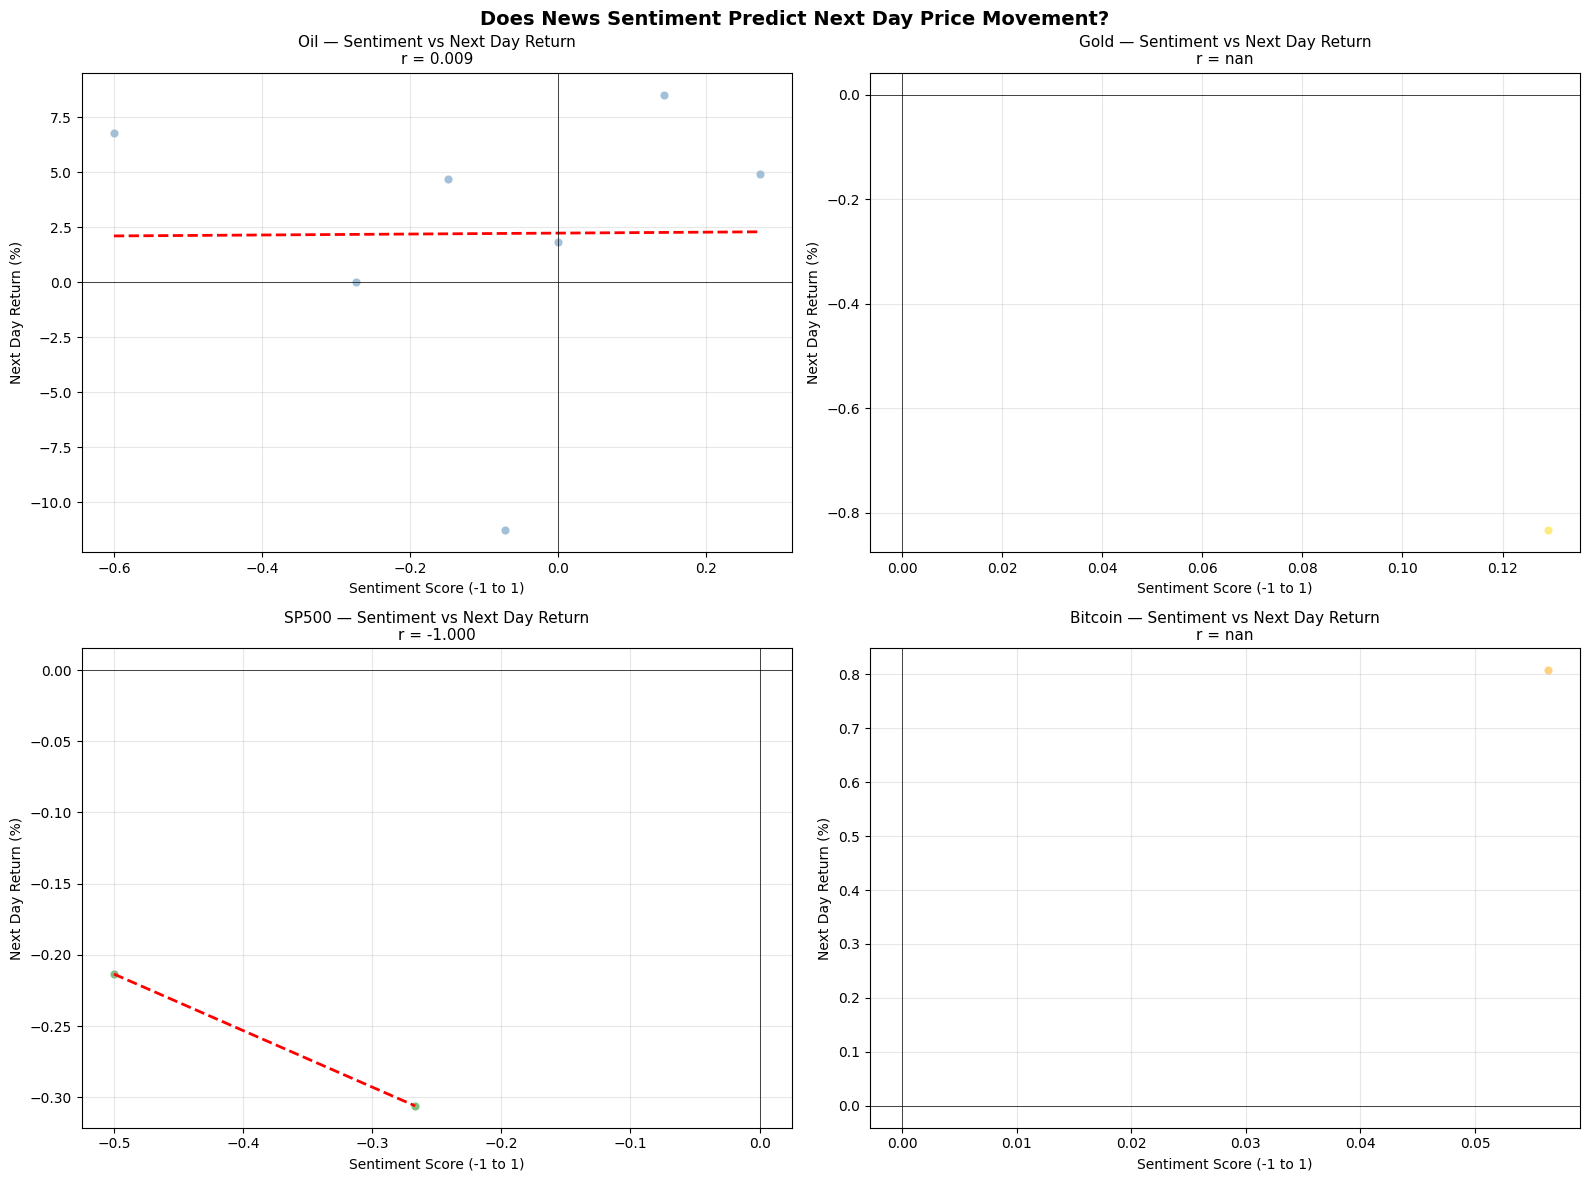

In [3]:
# ============================================================
# SENTIMENT VS PRICE MOVEMENT ANALYSIS
# ============================================================

sentiment["date"] = pd.to_datetime(sentiment["date"])

# Average daily sentiment per asset
daily_sentiment = sentiment.groupby(["date", "asset"])["sentiment_numeric"].mean().reset_index()
daily_sentiment.columns = ["date", "asset", "avg_sentiment"]

# Merge with prices
prices_sentiment = prices.merge(daily_sentiment, on=["date", "asset"], how="inner")

# Plot sentiment vs next day return
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
assets = ["Oil", "Gold", "SP500", "Bitcoin"]
colors = ["steelblue", "gold", "green", "orange"]

for idx, (asset, color) in enumerate(zip(assets, colors)):
    ax = axes[idx//2, idx%2]
    data = prices_sentiment[prices_sentiment["asset"] == asset].copy()
    data = data.sort_values("date")
    data["next_day_return"] = data["daily_return"].shift(-1)
    data = data.dropna()
    
    ax.scatter(data["avg_sentiment"], data["next_day_return"],
               color=color, alpha=0.5, edgecolors="white", linewidth=0.3)
    
    # Add trend line
    z = np.polyfit(data["avg_sentiment"], data["next_day_return"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data["avg_sentiment"].min(), data["avg_sentiment"].max(), 100)
    ax.plot(x_line, p(x_line), color="red", linewidth=2, linestyle="--")
    
    corr = data["avg_sentiment"].corr(data["next_day_return"])
    ax.set_title(f"{asset} — Sentiment vs Next Day Return\nr = {corr:.3f}", fontsize=11)
    ax.set_xlabel("Sentiment Score (-1 to 1)")
    ax.set_ylabel("Next Day Return (%)")
    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    ax.axvline(x=0, color="black", linestyle="-", linewidth=0.5)
    ax.grid(True, alpha=0.3)

plt.suptitle("Does News Sentiment Predict Next Day Price Movement?", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/sentiment_vs_returns.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
#Insufficient temporal overlap between news and price data prevented robust sentiment-price correlation analysis.
#A minimum of 6-12 months of concurrent news and price data would be required for meaningful results."